In [50]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [51]:
import re
import csv
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

results = []
with open("/content/hypothesisRunTest_output copy.txt") as f:
    for line in f:
        m = re.match(r'\s*tests/([\w]+)\.py::([\w]+)\s+(PASSED|FAILED)', line)
        if m:
            program = m.group(1)
            test = m.group(2)
            status = m.group(3)
            results.append((program, test, status))

print(f"Total rows: {len(results)}")

with open("test_results.csv", "w", newline="") as f:
    w = csv.writer(f)
    w.writerow(["Program", "Test Name", "Result"])
    w.writerows(results)

df_tr = pd.read_csv('test_results.csv')
df_tr['Program'] = df_tr['Program'].str.replace('test_', '')
df_tr

Total rows: 1498


,Program,Test Name,Result
0,hypothesis_test,test_preserves_length,FAILED
1,hypothesis_test,test_branch_specific_behavior,FAILED
2,hypothesis_test,test_return_postcondition_empty,PASSED
3,hypothesis_test,test_return_postcondition_normal,PASSED
4,hypothesis_test,test_loop_invariant,FAILED
...,...,...,...
1493,windowed_error_rate,test_preserves_length,PASSED
1494,windowed_error_rate,test_loop_invariant,PASSED
1495,windowed_error_rate,test_branch_specific_behavior_no_recent,PASSED
1496,windowed_error_rate,test_branch_specific_behavior_with_recent,FAILED


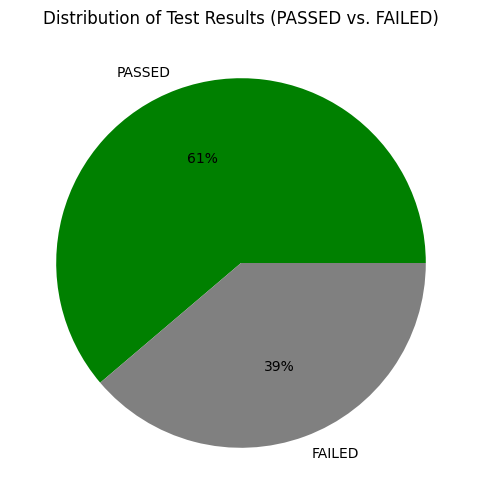

In [101]:
status_counts = df_tr['Result'].value_counts().reset_index()
status_counts.columns = ['Status', 'Count']

plt.figure(figsize=(8, 6))
plt.pie(status_counts.Count, labels=status_counts.Status ,colors=["Green","Grey"], autopct='%.0f%%')
plt.title('Distribution of Test Results (PASSED vs. FAILED)')
plt.show()

Summary of Top 10 and Other Generalized Test Cases:
                Test Category  FAILED  PASSED  Total   Accuracy
0        Loop Invariant Tests      89      56    145  38.620690
1      Preserves Length Tests      91     105    196  53.571429
2  Return Postcondition Tests     119     178    297  59.932660
3                       Other     154     262    416  62.980769
4       Branch Behavior Tests     128     316    444  71.171171


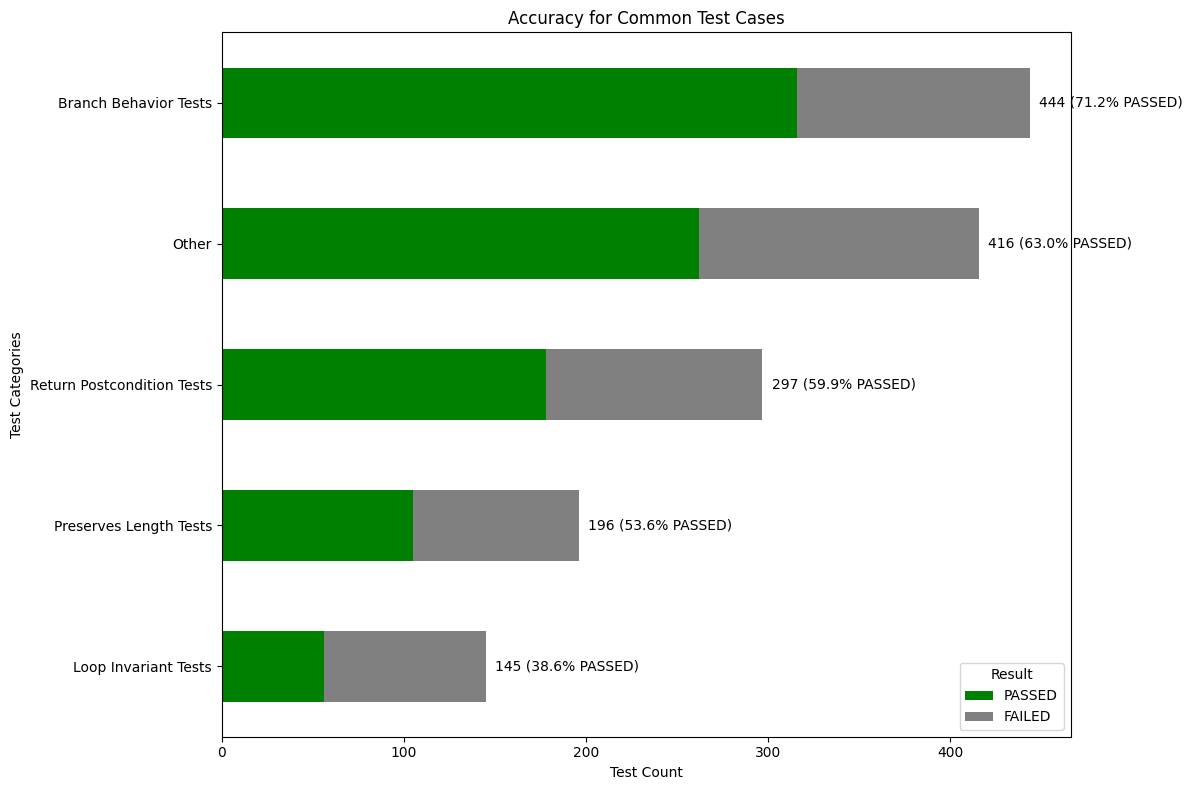

In [114]:
# Function to generalize test names by manually getting the five most common test prefixes
def generalize_test_name(test_name):
    if 'return_postcondition' in test_name:
      test_name = "Return Postcondition Tests"
    if 'test_loop_invariant' in test_name:
      test_name = "Loop Invariant Tests"
    if 'test_branch' in test_name:
      test_name = "Branch Behavior Tests"
    if 'test_preserve_length' in test_name or 'test_preserves_length' in test_name:
      test_name = "Preserves Length Tests"
    if 'test_return' in test_name:
      test_name = "Return Tests"
    return test_name

# Apply the generalization function
df_tr['Test Category'] = df_tr['Test Name'].apply(generalize_test_name)

# Group by the test category and count PASSED/FAILED
generalized_test_summary = df_tr.groupby(['Test Category', 'Result']).size().unstack(fill_value=0)

# Total count and accuracy
generalized_test_summary['Total'] = generalized_test_summary['PASSED'] + generalized_test_summary['FAILED']
generalized_test_summary['Accuracy'] = (generalized_test_summary['PASSED'] / generalized_test_summary['Total']) * 100

# Sort by total count find the most frequent generalized tests
generalized_test_summary_sorted = generalized_test_summary.sort_values(by='Total', ascending=False).reset_index()

# Get the top 4 tests
top_5_generalized_tests = generalized_test_summary_sorted.head(4).copy()

# Aggregate the rest into 'Other'
other_tests = generalized_test_summary_sorted.iloc[4:]
if not other_tests.empty:
    other_passed = other_tests['PASSED'].sum()
    other_failed = other_tests['FAILED'].sum()
    other_total = other_tests['Total'].sum()
    other_accuracy = (other_passed / other_total) * 100 if other_total > 0 else 0

    other_row = pd.DataFrame([{
        'Test Category': 'Other',
        'FAILED': other_failed,
        'PASSED': other_passed,
        'Total': other_total,
        'Accuracy': other_accuracy
    }])
    final_summary_for_plot = pd.concat([top_5_generalized_tests, other_row], ignore_index=True)
else:
    final_summary_for_plot = top_5_generalized_tests

# Sort by Total count before plotting
final_summary_for_plot = final_summary_for_plot.sort_values(by='Total', ascending=True).reset_index(drop=True)

print("Summary of Top 4 and Other Generalized Test Cases:")
print(final_summary_for_plot)

# Plot the stacked bar chart
plt.figure(figsize=(12, 8))
final_summary_for_plot[['PASSED', 'FAILED']].plot(kind='barh', stacked=True, color=['Green', 'Grey'], ax=plt.gca())
plt.title('Accuracy for Common Test Cases')
plt.xlabel('Test Count')
plt.ylabel('Test Categories')
plt.yticks(range(len(final_summary_for_plot)), final_summary_for_plot['Test Category'])
plt.legend(['PASSED', 'FAILED'], title='Result')

# Add labels
for index, row in final_summary_for_plot.iterrows():
    total_text = f"{int(row['Total'])}"
    accuracy_text = f" ({row['Accuracy']:.1f}% PASSED)"
    plt.text(row['Total'] + 5, index, total_text + accuracy_text, color='black', va='center')

plt.tight_layout()
plt.show()

In [103]:
import pandas as pd

# Group by Program and Result to count PASSED/FAILED tests for each program
program_summary = df_tr.groupby(['Program', 'Result']).size().unstack(fill_value=0)

# Calculate Total tests and Accuracy for each program
program_summary['Total'] = program_summary['PASSED'] + program_summary['FAILED']
program_summary['Accuracy'] = (program_summary['PASSED'] / program_summary['Total']) * 100

# Sort by Accuracy to easily see the best/worst performing programs
program_summary_sorted = program_summary.sort_values(by='Accuracy', ascending=False).reset_index()

print("Program Accuracy Summary:")
print(program_summary_sorted.round(2)) # Round to 2 decimal places for better readability

Program Accuracy Summary:
Result               Program  FAILED  PASSED  Total  Accuracy
0        allocate_budget_cut       0       9      9     100.0
1       attention_mask_merge       0       4      4     100.0
2               billing_gate       0       4      4     100.0
3             api_rate_guard       0       4      4     100.0
4               cached_route       0       6      6     100.0
..                       ...     ...     ...    ...       ...
244            prices_stream       7       0      7       0.0
245            realign_power       1       0      1       0.0
246        probability_curve       6       0      6       0.0
247          schedule_window       6       0      6       0.0
248          votes_apportion      10       0     10       0.0

[249 rows x 5 columns]


In [110]:
import pandas as pd

# Define the bins for accuracy percentages
bins = [0, 10, 20, 30, 40, 50, 60, 70, 80, 90, 99, 100]
labels = ['0-10%', '11-20%', '21-30%', '31-40%', '41-50%', '51-60%', '61-70%', '71-80%', '81-90%', '91-99%','100%']

# Categorize programs by their accuracy
program_summary_sorted['Accuracy_Category'] = pd.cut(program_summary_sorted['Accuracy'], bins=bins, labels=labels, right=True, include_lowest=True)

# Count the number of programs in each category
accuracy_distribution = program_summary_sorted['Accuracy_Category'].value_counts().sort_index()

print("Number of Programs by Accuracy Category:")
print(accuracy_distribution)

Number of Programs by Accuracy Category:
Accuracy_Category
0-10%     18
11-20%    26
21-30%     7
31-40%    18
41-50%    35
51-60%    19
61-70%     7
71-80%    35
81-90%    23
91-99%     1
100%      60
Name: count, dtype: int64


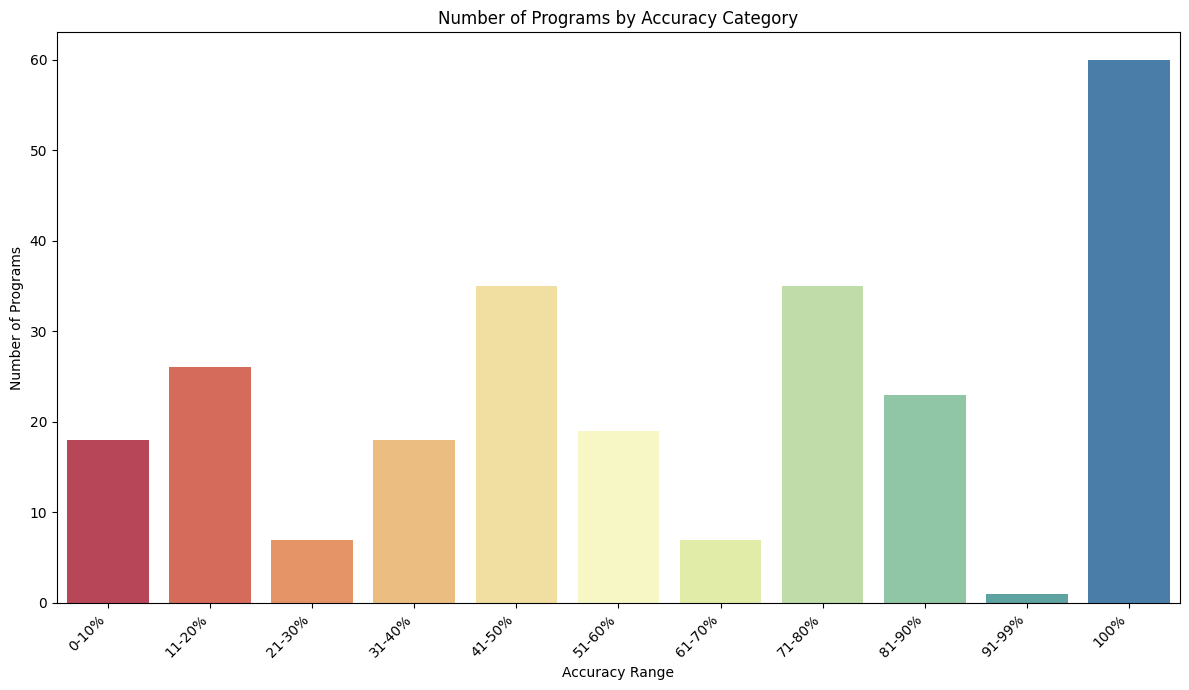

In [113]:
import matplotlib.pyplot as plt
import seaborn as sns

# Plot accuracy_df
accuracy_df = accuracy_distribution.reset_index()
accuracy_df.columns = ['Accuracy_Category', 'Number of Programs']

plt.figure(figsize=(12, 7))
sns.barplot(x='Accuracy_Category', y='Number of Programs', data=accuracy_df, palette='Spectral', hue='Accuracy_Category', legend=False)
plt.title('Number of Programs by Accuracy Category')
plt.xlabel('Accuracy Range')
plt.ylabel('Number of Programs')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()